In [31]:
# -------------------- Imports --------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

In [32]:
# -------------------- Load Dataset --------------------
data = pd.read_csv('creditcard.csv')
data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [33]:
# -------------------- Preprocessing --------------------
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])
data = data.drop(['Time'], axis=1)

X = data.drop('Class', axis=1)
y = data['Class']


In [ ]:
# -------------------- Train-Test Split --------------------

import pickle

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Save the test set for the dashboard
with open('X_test.pkl', 'wb') as f:
    pickle.dump(X_test, f)

with open('y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)

print("X_test and y_test saved for dashboard.")
# -------------------- Handle Class Imbalance (SMOTE) --------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


X_test and y_test saved for dashboard.


In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier

# -------------------- Subsample for Fast GridSearch --------------------
# Use stratified sampling to keep class distribution
X_sub, _, y_sub, _ = train_test_split(
    X_train_res, y_train_res, train_size=20000, stratify=y_train_res, random_state=42
)

# -------------------- Parameter Grid --------------------
param_grid = {
    'n_estimators': [50, 100, 150],       # a slightly wider range
    'max_depth': [None, 10, 20, 30],      # allow slightly deeper trees
    'min_samples_split': [2, 5, 10],      # try one higher value
    'min_samples_leaf': [1, 2, 4],        # add leaf control to prevent overfitting
    'class_weight': ['balanced']          # keep for imbalance handling
}

# -------------------- Stratified K-Fold --------------------
cv_strategy = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# -------------------- GridSearch --------------------
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',       # focus on fraud detection
    cv=cv_strategy,
    n_jobs=-1,          # use all CPU cores
    verbose=2
)

grid_search.fit(X_sub, y_sub)

print("Best Parameters Found:", grid_search.best_params_)

Fitting 2 folds for each of 108 candidates, totalling 216 fits
Best Parameters Found: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}


In [36]:
# -------------------- Train Final Model on Full Resampled Data --------------------
from sklearn.ensemble import RandomForestClassifier
import pickle

# Use the best parameters from GridSearch
best_params = grid_search.best_params_

best_rf = RandomForestClassifier(**best_params, random_state=42)
best_rf.fit(X_train_res, y_train_res)

# -------------------- Save Model --------------------
with open('best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print("Final model trained on full data and saved as 'best_rf_model.pkl'.")

Final model trained on full data and saved as 'best_rf_model.pkl'.


Confusion Matrix:
 [[56852    12]
 [   17    81]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9720071448669507
Precision-Recall AUC: 0.8730450083873512


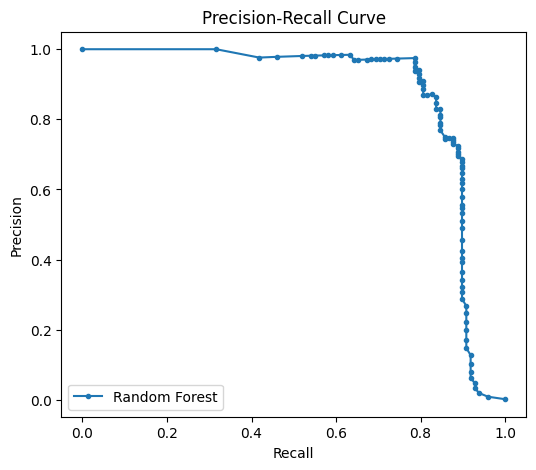

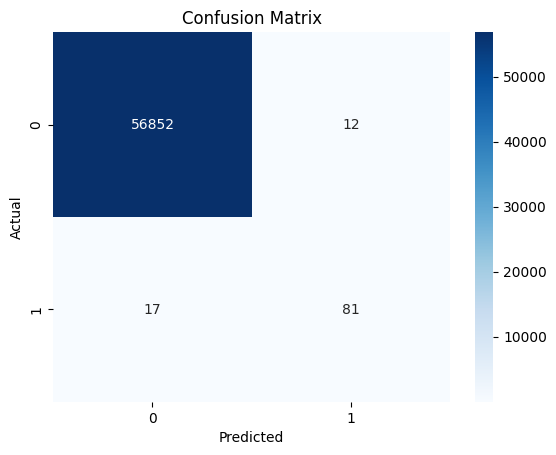

In [37]:
# -------------------- Evaluation --------------------
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on test set
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:,1]  # probability for positive class

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC-AUC Score
roc = roc_auc_score(y_test, y_proba)
print("\nROC-AUC Score:", roc)

# -------------------- Precision-Recall Curve --------------------
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print("Precision-Recall AUC:", pr_auc)

# Plot PR curve
plt.figure(figsize=(6,5))
plt.plot(recall, precision, marker='.', label='Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Optional: Confusion Matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()